<a href="https://colab.research.google.com/github/salma-mahmoud237/Deep-Learning/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [ ]:
# Device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [ ]:
# Data Preprocessing

transform_train = transforms.Compose([

    transforms.Resize((28,28)),              # Resizing
    transforms.RandomRotation(10),           # Data Augmentation
    transforms.RandomHorizontalFlip(),       # Data Augmentation

    transforms.ToTensor(),                   # Convert image to tensor

    transforms.Normalize((0.5,), (0.5,))    # Normalization
])

transform_test = transforms.Compose([

    transforms.Resize((28,28)),              # Resizing

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
# Load Dataset

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

# Encoding Labels
# MNIST labels are already encoded from 0 to 9

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.05MB/s]


In [ ]:
# DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

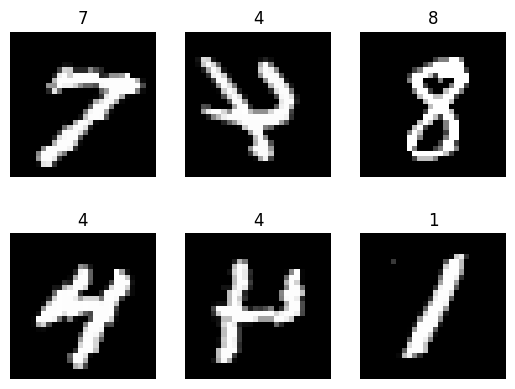

In [ ]:
# Display Images

examples = iter(train_loader)
images, labels = next(examples)

for i in range(6):

    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(labels[i].item())
    plt.axis('off')

plt.show()

In [ ]:
# CNN Model

class CNNModel(nn.Module):

    def __init__(self):

        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.batchnorm1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.batchnorm2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2)

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)

        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.batchnorm2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [ ]:
# Experiment 1 (Adam)

model1 = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()

optimizer1 = optim.Adam(
    model1.parameters(),
    lr=0.001
)

In [ ]:
# Training Experiment 1

train_loss1 = []
train_acc1 = []

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    model1.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer1.zero_grad()

        outputs = model1(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer1.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100 * correct / total

    train_loss1.append(epoch_loss)

    train_acc1.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/5]
Loss: 0.4670
Accuracy: 84.83%
Epoch [2/5]
Loss: 0.2666
Accuracy: 91.52%
Epoch [3/5]
Loss: 0.2205
Accuracy: 93.25%
Epoch [4/5]
Loss: 0.1981
Accuracy: 93.77%
Epoch [5/5]
Loss: 0.1771
Accuracy: 94.64%


In [ ]:
# Test Experiment 1

model1.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model1(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy1 = 100 * correct / total

loss1 = test_loss / len(test_loader)

print("Test Accuracy:", accuracy1)
print("Test Loss:", loss1)

Test Accuracy: 98.2
Test Loss: 0.052726502912797506


In [ ]:
# Experiment 2 (SGD)

model2 = CNNModel().to(device)

optimizer2 = optim.SGD(
    model2.parameters(),
    lr=0.01
)

In [ ]:
# Training Experiment 2

train_loss2 = []
train_acc2 = []

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0
    correct = 0
    total = 0

    model2.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer2.zero_grad()

        outputs = model2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer2.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100 * correct / total

    train_loss2.append(epoch_loss)

    train_acc2.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Accuracy: {epoch_acc:.2f}%")

Epoch [1/5]
Loss: 0.6046
Accuracy: 81.08%
Epoch [2/5]
Loss: 0.2825
Accuracy: 91.16%
Epoch [3/5]
Loss: 0.2151
Accuracy: 93.62%
Epoch [4/5]
Loss: 0.1784
Accuracy: 94.69%
Epoch [5/5]
Loss: 0.1624
Accuracy: 95.12%


In [ ]:
# Test Experiment 2

model2.eval()

correct = 0
total = 0
test_loss = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy2 = 100 * correct / total

loss2 = test_loss / len(test_loader)

print("Test Accuracy:", accuracy2)
print("Test Loss:", loss2)

Test Accuracy: 97.7
Test Loss: 0.07291076984998004


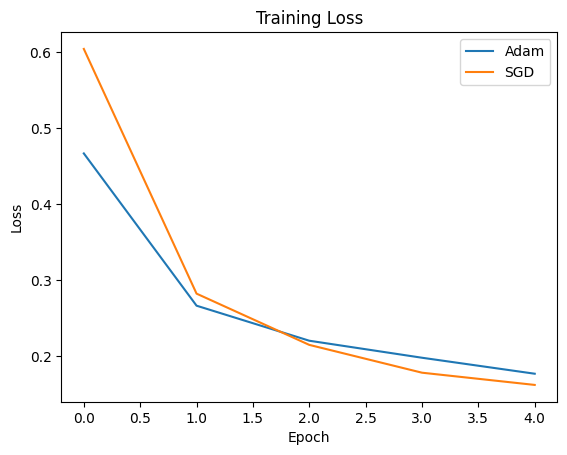

In [ ]:
# Loss Graph

plt.plot(train_loss1, label='Adam')

plt.plot(train_loss2, label='SGD')

plt.title('Training Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

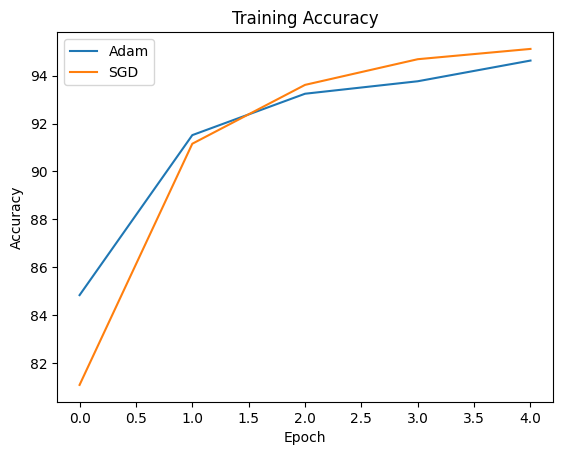

In [ ]:
# Accuracy Graph

plt.plot(train_acc1, label='Adam')

plt.plot(train_acc2, label='SGD')

plt.title('Training Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [ ]:
# Comparison Table

print("===================================")
print("Model\t\tAccuracy\tLoss")
print("===================================")

print(f"CNN + Adam\t{accuracy1:.2f}%\t\t{loss1:.4f}")

print(f"CNN + SGD\t{accuracy2:.2f}%\t\t{loss2:.4f}")

Model		Accuracy	Loss
CNN + Adam	98.20%		0.0527
CNN + SGD	97.70%		0.0729
